# GFDL vertical sections: forced-ocean parameterization comparison

Latitude-depth sections of the zonally-averaged temperature, salinity and
potential density (sigma2) bias/response, the zonal-mean meridional isopycnal
slope, and regional sigma2 sections (Drake Passage, Weddell Sea, basin zonal
averages, equatorial longitude-depth averages) for GFDL's 4 forced-ocean
experiments -- the same content as CESM's `vertical_sections.ipynb`, in the
same style: column 1 is always `CTRL - WOA18`, every other column is that
experiment's **response relative to CTRL** (`exp - CTRL`).

GFDL's grid is regular 1x1 degree, but `zonal_ave` below still bins by true
`geolat` (not a plain `xh`-mean) -- identical to the CESM notebook's own
tripolar-safe implementation, which works unchanged on any grid where
`geolat` is a genuine 2D field (regular or curvilinear).

Basin masks come from GFDL's own native `basin` field (see below), not
`mom6_tools.m6toolbox.genBasinMasks` -- that function's cutting-line geometry
is tuned for CESM's specific tripolar grid and gives wrong/empty basins on
GFDL's grid even after fixing the two bugs that block it from running at all
(see [`gfdl_shim.py`](../gfdl_shim.py)).

**Averaging window: 1988-2012** (24 years), mirroring the CESM convention in
`forced_noGM.yaml` (model years 31-55), translated via GFDL's real-calendar
epoch (year 1 = 1958). This window is entirely after the `CTRL`/`bANN` branch
point (Jan 1983 -- `bANN`'s data is bit-identical to `CTRL`'s before that date),
so it doesn't dilute `bANN`'s signal with years where its parameterization
wasn't yet active.

**Scope**: `thetao`/`so` (+ derived sigma2) only, following
[`gfdl_time_series.ipynb`](gfdl_time_series.ipynb) (which still covers each
experiment's full available record, not just this window).

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import gsw
import nc_time_axis  # lets matplotlib plot GFDL's cftime (julian calendar) axis directly
from mom6_tools.m6plot import myStats

from experiment import Experiment

# mom6_tools.m6plot forces matplotlib.use('Agg') at import time (for headless
# HPC batch plotting) -- this silently overrides Jupyter's own inline backend,
# so plt.show() below would otherwise produce no output at all, with no error.
%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('YAML_DIR =', YAML_DIR)
print('GFDL_DIR =', GFDL_DIR)


Basemap module not found. Some regional plots may not function properly
REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + grid, and never triggers heavy computation.

Layout follows CESM's `horizontal_biases.ipynb`/`vertical_sections.ipynb`
convention exactly -- column 1 is always `CTRL - WOA18` (the control's own
bias against observations), and every other column is that experiment's
**response relative to CTRL** (`exp - CTRL`), not a second bias-vs-obs map.
GFDL has one row instead of CESM's two (coupled/forced) since these are all
forced-ocean runs, and four columns instead of three (`bANN`, `uANN`, and
`bANN_uANN` all respond independently to `CTRL`, vs. CESM's single `bANN`).


In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'   # response baseline for every non-CTRL column

# Short legend labels
LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}

print('Initialized:', names)


[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


MOM6 grid successfully loaded... 



[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


## Basin masks, from GFDL's own native `basin` field

`mom6_tools.m6toolbox.genBasinMasks` (used by the CESM notebooks) is built
around CESM's specific tripolar grid geometry -- its hardcoded seed points and
cutting lines assume that grid's particular longitude wrap and indexing, and
two bugs specific to that (a NaN-argmin edge case, and a wrap-convention
mismatch) had to be patched in `gfdl_shim.py` just to get *any* basin
assigned. Even patched, several basins (Atlantic/Pacific/Arctic/...) still
come back empty or wrong on this grid -- the algorithm's cutting-line geometry
itself is tuned for CESM's grid, not GFDL's.

GFDL's own static file already carries a `basin` field (`flag_meanings: 1:
Southern Ocean, 2:Atlantic Ocean, ...` -- the exact same numbering
`genBasinMasks` uses), computed correctly for GFDL's own grid by GFDL's own
postprocessing. This builds `basin_code_xr` directly from that field instead
(rounded to the nearest integer -- it's fractional at coastlines from
conservative-remap blending) rather than re-deriving it from CESM-specific
flood-fill geometry.


In [3]:
BASIN_NAMES = {1: 'SouthernOcean', 2: 'AtlanticOcean', 3: 'PacificOcean', 4: 'Arctic',
              5: 'IndianOcean', 6: 'MedSea', 7: 'BlackSea', 8: 'HudsonBay',
              9: 'BalticSea', 10: 'RedSea', 11: 'PersianGulf'}


def build_basin_code_xr(exp):
    basin_int = np.round(exp.grd.basin.values)
    wet = exp.grd.wet.values
    regions = list(BASIN_NAMES.values())
    data = np.stack([np.where((wet > 0) & (basin_int == code), 1.0, 0.0)
                     for code in BASIN_NAMES], axis=0)
    return xr.DataArray(data, dims=('region', 'yh', 'xh'), coords={'region': regions})


basin_code_xr = build_basin_code_xr(exps[CTRL])
atl_mask = (basin_code_xr.sel(region='AtlanticOcean') + basin_code_xr.sel(region='Arctic') +
            basin_code_xr.sel(region='MedSea') + basin_code_xr.sel(region='BlackSea') +
            basin_code_xr.sel(region='HudsonBay'))
pac_mask = basin_code_xr.sel(region='PacificOcean')
ind_mask = basin_code_xr.sel(region='IndianOcean')
so_mask = basin_code_xr.sum('region')  # all ocean basins (true global zonal average)

print('basin mask sizes (grid cells): Atlantic+=', int(atl_mask.sum().values),
      ' Pacific=', int(pac_mask.sum().values),
      ' Indian=', int(ind_mask.sum().values),
      ' All-ocean=', int(so_mask.sum().values))


basin mask sizes (grid cells): Atlantic+= 13453  Pacific= 13400  Indian= 3512  All-ocean= 43845


## Shared machinery (zonal average, piecewise depth axis, sigma2)

`zonal_ave`, the piecewise-stretched depth axis (0-200, 200-1000, 1000-5500 m
each getting 1/3 of the plot height), and `obs_sigma2` (WOA-2018 recovered as
`model - bias`) are ported unchanged from CESM's `vertical_sections.ipynb`.


In [4]:
def zonal_ave(array, geolat):
    """Bin a field into 1-degree latitude bands using true geolat (works for
    any grid where geolat is a genuine 2D field, tripolar or regular)."""
    bins = array.yh.values
    bins = (bins[:-1] + bins[1:]) / 2
    return array.groupby_bins(geolat, bins=bins).mean()


# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]


def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))


def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))


def obs_sigma2(exp):
    """Observational sigma2 (WOA-2018) recovered from model field minus bias."""
    t = exp.thetao()
    s = exp.so()
    thetao_obs = t.thetao - t.thetao_bias
    so_obs = s.so - s.so_bias
    return gsw.sigma2(so_obs, thetao_obs)


# Contour levels shared throughout
DZONAL_LEVELS = np.arange(-0.275, 0.28, 0.05)   # sigma2 bias filled contours
SIGMA2_LEVELS = np.arange(30.0, 37.51, 0.5)      # observed sigma2 isolines


## Shared bias/response section plotter

Column 1: `CTRL - WOA18`. Columns 2-4: response of `bANN`/`uANN`/`bANN_uANN`
relative to `CTRL` (`exp - CTRL`). RMSE is always vs WOA18 -- identical
convention to CESM's `plot_bias_zonal`.


In [5]:
def plot_bias_zonal(get_bias, diff_levels, cmap, quantity, unit, cbar_label,
                    rmse_fmt='.2f'):
    # 1x4 latitude-depth zonal-average bias (model - WOA18) and exp - CTRL response.
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    geolat = exps[CTRL].grd.geolat
    ctrl_bias = get_bias(exps[CTRL])            # (z_l, yh, xh) = model - WOA18
    for col, name in enumerate(names):
        ax = axes[col]
        bias = get_bias(exps[name])
        bias_za = zonal_ave(bias, geolat)
        if col == 0:
            field_za = bias_za
            title = f'{LABELS[name]} ' + r'$-$' + ' WOA18'
        else:
            field_za = zonal_ave(bias - ctrl_bias, geolat)
            title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
        rmse = float(np.sqrt((bias_za ** 2).mean()))   # RMSE always vs WOA18
        im = field_za.plot.contourf(ax=ax, levels=diff_levels, cmap=cmap,
                                    extend='both', add_colorbar=False)
        ax.set_title(f'{title}\nRMSE={rmse:{rmse_fmt}} {unit}')
        ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
        ax.set_ylim(d_edges[3], d_edges[0])
        ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
        for d in (d_edges[1], d_edges[2]):
            ax.axhline(d, color='0.5', lw=0.8, ls='--')
        ax.set_xlim([-80, 80])
        ax.set_xlabel('Latitude')
        ax.set_ylabel('Depth [m]' if col == 0 else '')
        ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, label=cbar_label, extend='both',
                        ticks=diff_levels, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in diff_levels])
    fig.suptitle(f'Zonally-averaged {quantity.lower()} bias (model $-$ WOA18) '
                 'and response patterns', fontsize=26)
    plt.show()


# Temperature zonal levels: same continuous colorbar as horizontal_biases.ipynb's
# maps, range reduced 2x (+/-0.9 degC); 0.0 is not a level boundary.
TZONAL_LEVELS = np.arange(-0.9, 0.91, 0.2)


def plot_thetao_zonal():
    plot_bias_zonal(lambda e: e.thetao().thetao_bias, TZONAL_LEVELS, 'RdYlBu_r',
                    'Temperature', r'$^\circ$C', r'Temperature bias [$^\circ$C]')


# Salinity neutral-band colormap (ported from horizontal_biases.ipynb): a wide
# central bin (|bias| < 0.1 PSU) is drawn as a single neutral color instead of
# flipping hue across zero.
SBIAS_LEVELS = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, -0.1,
                         0.1, 0.2, 0.4, 0.6, 0.8, 1.0])   # PSU
_s_base = plt.get_cmap('RdYlBu_r')
_s_nbins = len(SBIAS_LEVELS) - 1
_s_colors = list(_s_base(np.linspace(0, 1, _s_nbins)))
_s_colors[_s_nbins // 2] = (1.0, 1.0, 1.0, 1.0)   # neutral for [-0.1, 0.1] PSU
S_CMAP = mpl.colors.ListedColormap(_s_colors)
S_CMAP.set_under(_s_base(0.0))
S_CMAP.set_over(_s_base(1.0))

# Salinity zonal levels: reuse S_CMAP's neutral-band colorbar with the range
# reduced 2x (+/-0.5 PSU) and 0.0 excluded (neutral [-0.05, 0.05] bin).
SZONAL_LEVELS = np.array([-0.5, -0.4, -0.3, -0.2, -0.1, -0.05,
                          0.05, 0.1, 0.2, 0.3, 0.4, 0.5])


def plot_so_zonal():
    plot_bias_zonal(lambda e: e.so().so_bias, SZONAL_LEVELS, S_CMAP,
                    'Salinity', 'PSU', 'Salinity bias [PSU]')


# 1. Zonally-averaged temperature bias and response

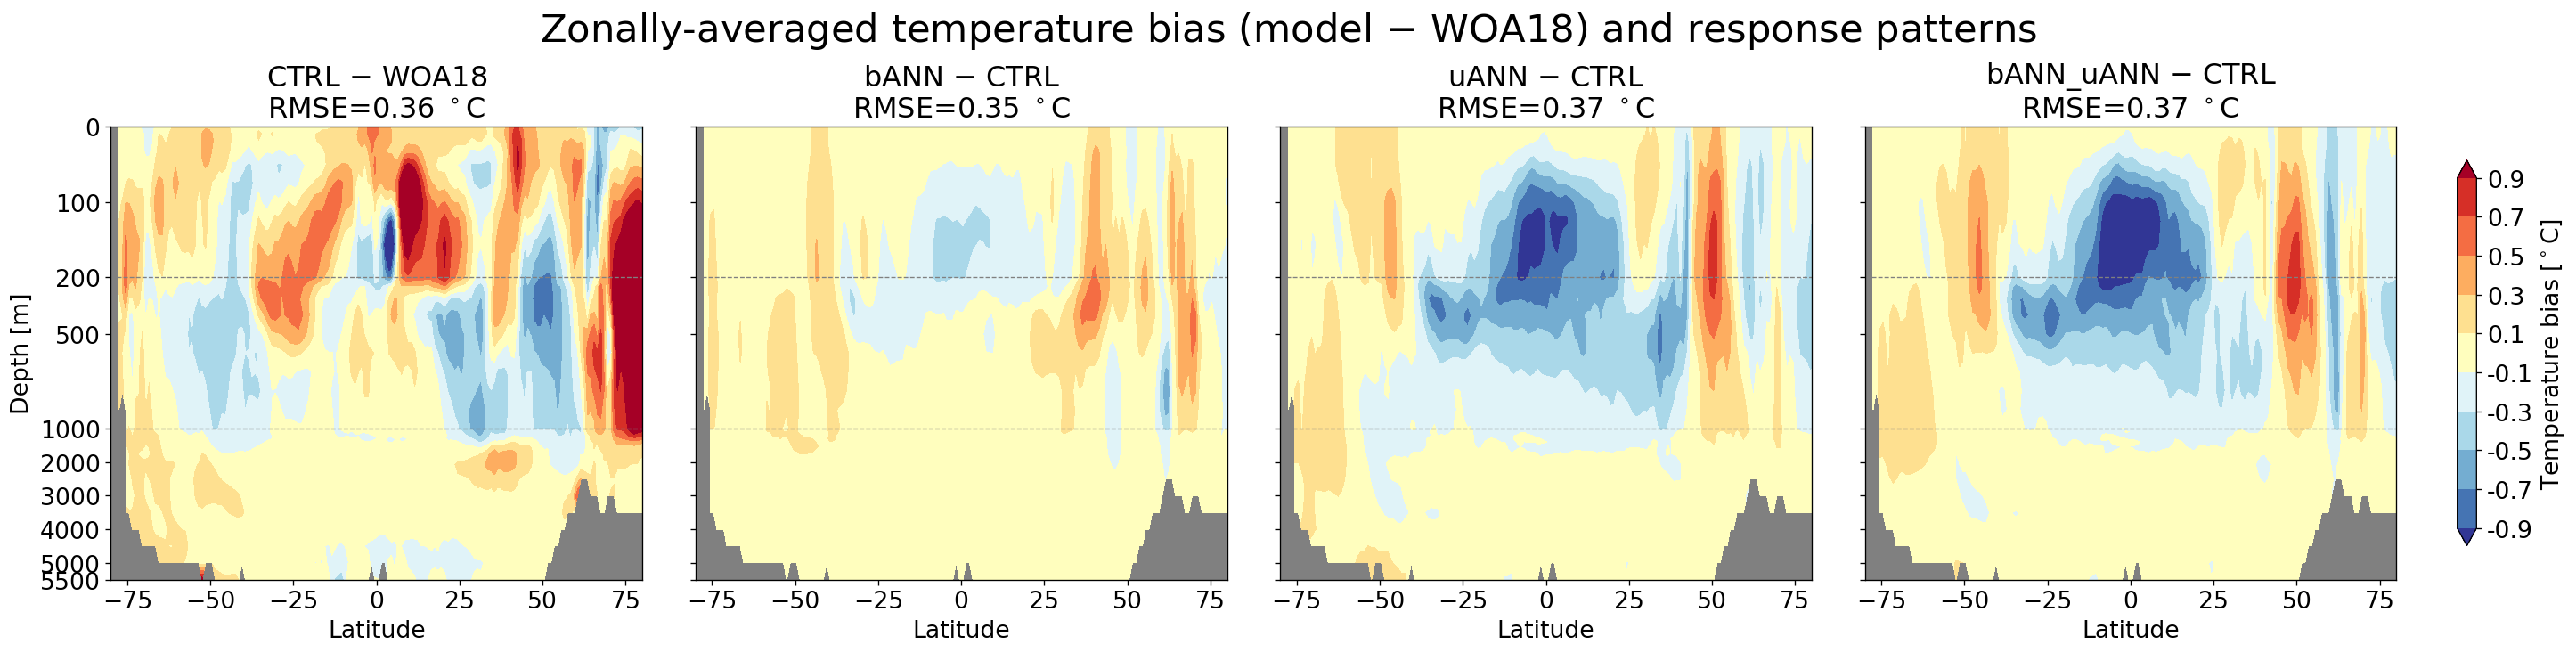

In [6]:
plot_thetao_zonal()

# 2. Zonally-averaged salinity bias and response

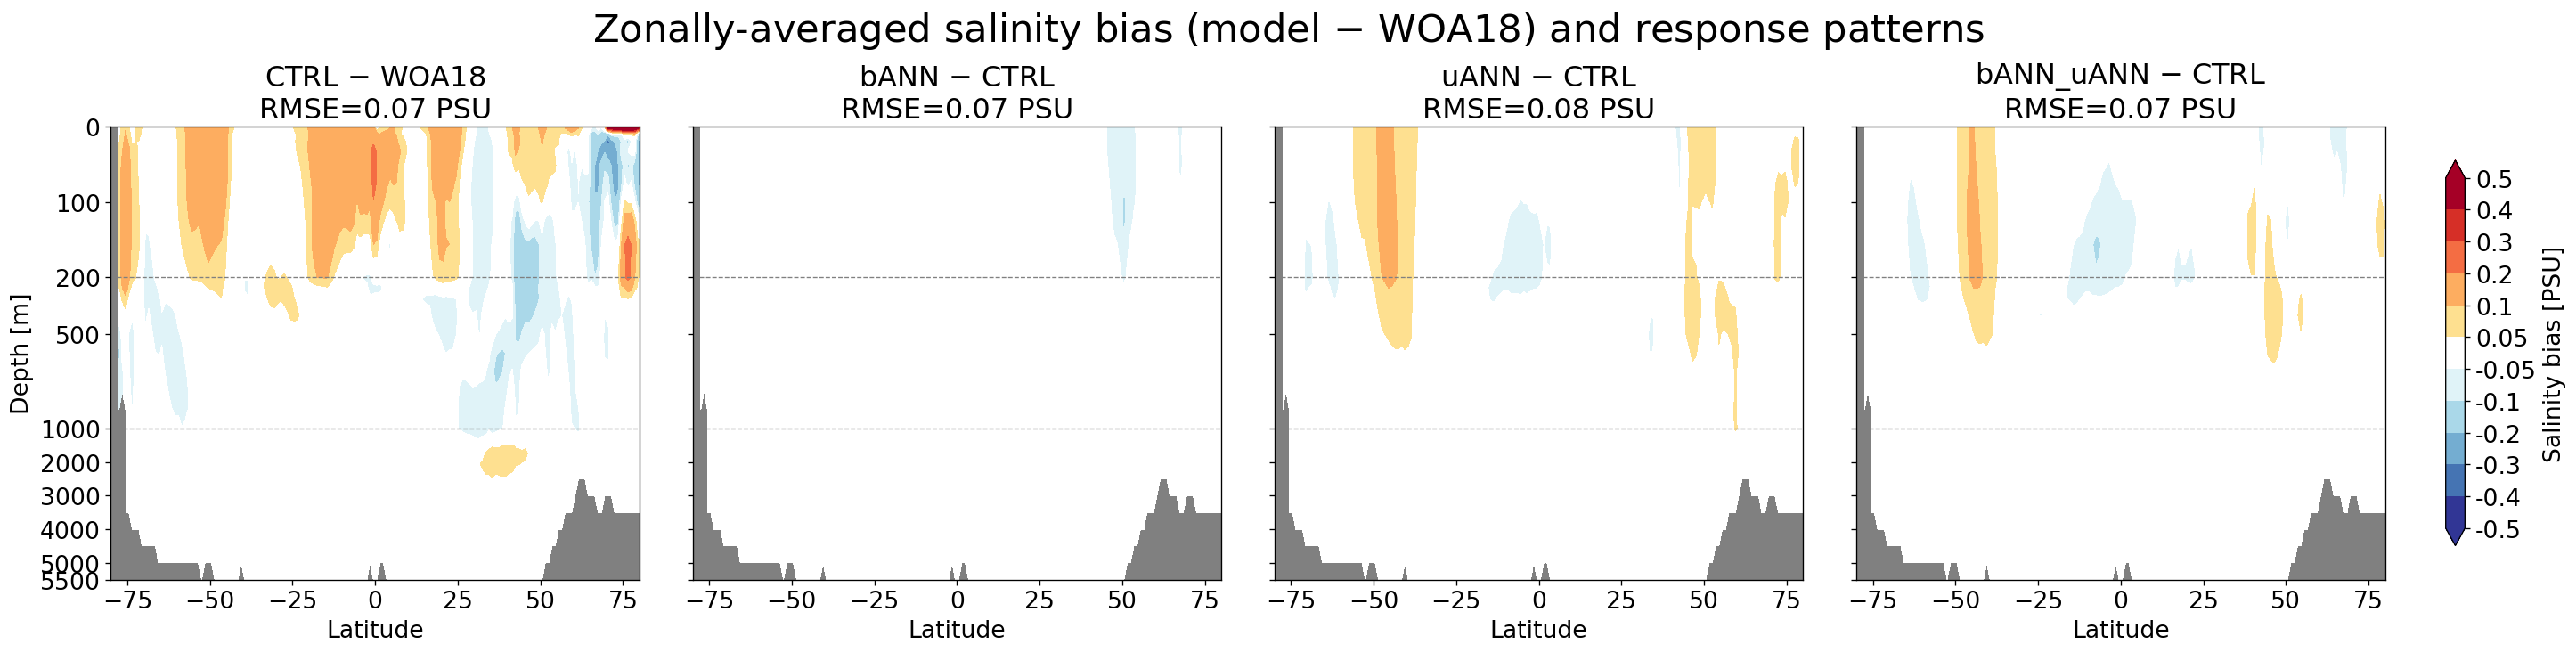

In [7]:
plot_so_zonal()

# 3. Zonally-averaged potential density (sigma2) bias and response

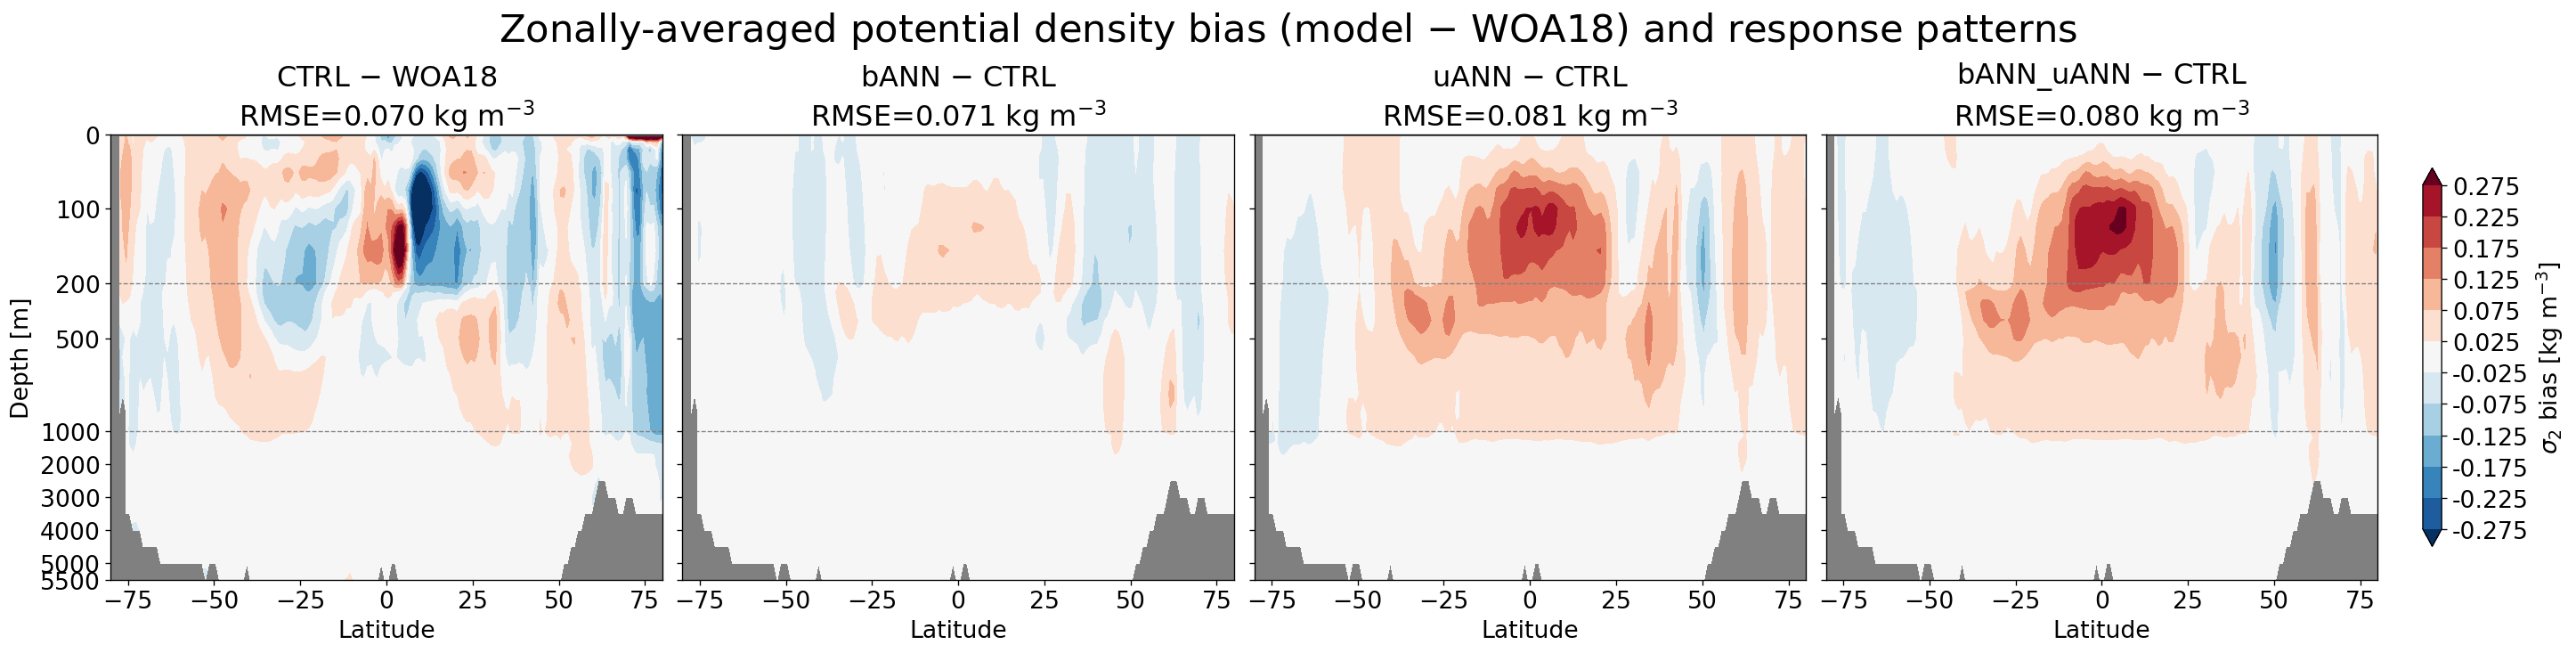

In [8]:
def plot_sigma2_zonal():
    plot_bias_zonal(lambda e: e.sigma2() - obs_sigma2(e), DZONAL_LEVELS, 'RdBu_r',
                    'Potential density', r'kg m$^{-3}$',
                    r'$\sigma_2$ bias [kg m$^{-3}$]', rmse_fmt='.3f')

plot_sigma2_zonal()


# 4. Zonal-mean meridional isopycnal slope

Following Danabasoglu & Marshall (2007, Fig. 4): the time- and zonal-mean
meridional isopycnal slope of sigma2 potential density, using the regularized
(bounded) definition $S_y = \partial_y\rho / \sqrt{(\partial_y\rho)^2 + (\partial_z\rho)^2}$.
Column 1: observed slope (WOA18), with observed sigma2 isopycnals overlaid.
Column 2: `CTRL - WOA18` bias in slope. Columns 3-5: response of
`bANN`/`uANN`/`bANN_uANN` relative to `CTRL`.


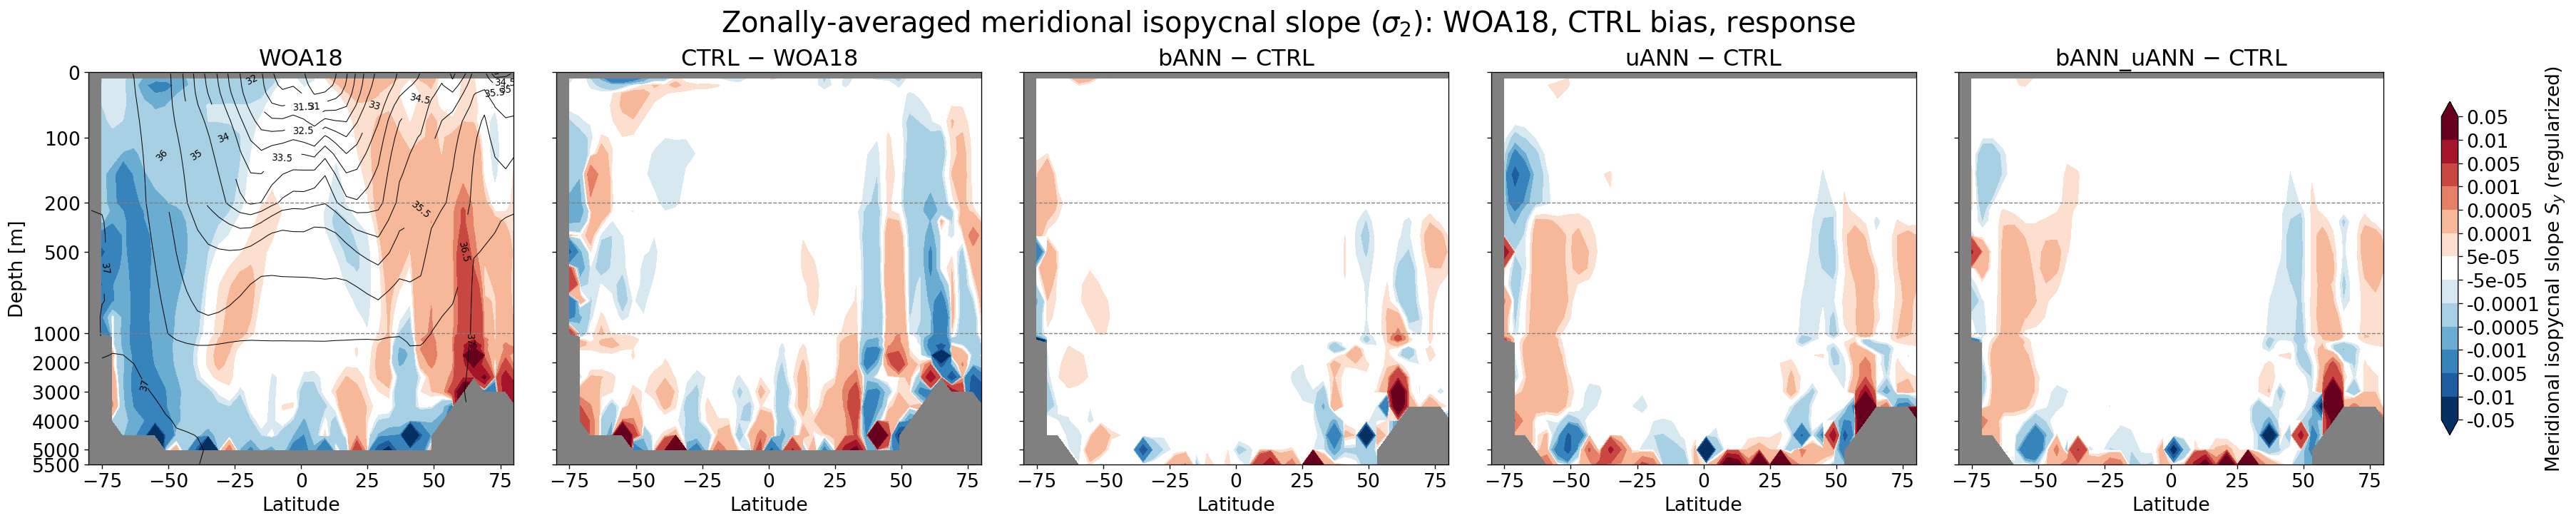

In [9]:
R_EARTH = 6371.0e3  # m
SLOPE_COARSEN = 4   # coarse-grain factor in the latitude direction (1 = off)


def _grad_masked(field, coord, axis):
    # np.gradient along `axis`, but any point whose 3-point stencil touches a
    # NaN (land / ocean boundary) is set to NaN so slopes are not contaminated
    # by one-sided differences across the boundary.
    g = np.gradient(field, coord, axis=axis)
    finite = np.isfinite(field)
    valid = finite & np.roll(finite, 1, axis=axis) & np.roll(finite, -1, axis=axis)
    edge = [slice(None)] * field.ndim
    edge[axis] = 0
    valid[tuple(edge)] = False
    edge[axis] = -1
    valid[tuple(edge)] = False
    return np.where(valid, g, np.nan)


def zonal_mean_density(sigma2, geolat, coarsen=SLOPE_COARSEN):
    zm = zonal_ave(sigma2, geolat)                     # (z_l, geolat_bins)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    if coarsen and coarsen > 1:
        zm = zm.coarsen(lat=coarsen, boundary='trim').mean()
    return zm                                          # (z_l, lat)


def slope_from_density(zm):
    lat = zm['lat'].values.astype(float)
    z = zm['z_l'].values.astype(float)                 # depth [m], positive down
    rho = zm.values                                    # (nz, nlat)
    y = np.deg2rad(lat) * R_EARTH                       # meridional distance [m]
    drho_dy = _grad_masked(rho, y, axis=1)
    drho_dz = _grad_masked(rho, z, axis=0)              # d rho / d(depth)
    slope = drho_dy / np.sqrt(drho_dy ** 2 + drho_dz ** 2)
    return xr.DataArray(slope, dims=('z_l', 'lat'),
                        coords={'z_l': z, 'lat': lat})


def zonal_isopycnal_slope(sigma2, geolat, coarsen=SLOPE_COARSEN):
    return slope_from_density(zonal_mean_density(sigma2, geolat, coarsen))


# Danabasoglu-style double-logarithmic (symlog) scale. No 0.0 boundary: the
# central bin [-5e-5, 5e-5] is a single, exactly-white neutral band.
_pos = np.array([5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2])
SLOPE_LEVELS = np.concatenate([-_pos[::-1], _pos])
_slope_base = plt.get_cmap('RdBu_r')
_slope_nb = len(SLOPE_LEVELS) - 1
_slope_colors = list(_slope_base(np.linspace(0, 1, _slope_nb)))
_slope_colors[_slope_nb // 2] = (1.0, 1.0, 1.0, 1.0)   # white for [-5e-5, 5e-5]
SLOPE_CMAP = mpl.colors.ListedColormap(_slope_colors)
SLOPE_CMAP.set_under(_slope_base(0.0))
SLOPE_CMAP.set_over(_slope_base(1.0))


def plot_slope_zonal(levels=SLOPE_LEVELS):
    # 1x5: obs slope, CTRL bias, then bANN/uANN/bANN_uANN response.
    geolat = exps[CTRL].grd.geolat
    obs_slope = zonal_isopycnal_slope(obs_sigma2(exps[CTRL]), geolat)
    ctrl_slope = zonal_isopycnal_slope(exps[CTRL].sigma2(), geolat)
    obs_rho = zonal_mean_density(obs_sigma2(exps[CTRL]), geolat)
    panels = [(obs_slope, 'WOA18', obs_rho),
              (ctrl_slope - obs_slope, 'CTRL $-$ WOA18', None)]
    for name in names[1:]:
        exp_slope = zonal_isopycnal_slope(exps[name].sigma2(), geolat)
        panels.append((exp_slope - ctrl_slope, f'{LABELS[name]} $-$ CTRL', None))

    fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    for col, (field, title, rho_overlay) in enumerate(panels):
        ax = axes[col]
        im = field.plot.contourf(ax=ax, levels=levels, cmap=SLOPE_CMAP,
                                 extend='both', add_colorbar=False)
        if rho_overlay is not None:
            cs = rho_overlay.plot.contour(ax=ax, levels=SIGMA2_LEVELS,
                                          colors='k', linewidths=0.6)
            ax.clabel(cs, fmt='%g', fontsize=8)
        ax.set_title(title)
        ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
        ax.set_ylim(d_edges[3], d_edges[0])
        ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
        for d in (d_edges[1], d_edges[2]):
            ax.axhline(d, color='0.5', lw=0.8, ls='--')
        ax.set_xlim([-80, 80])
        ax.set_xlabel('Latitude')
        ax.set_ylabel('Depth [m]' if col == 0 else '')
        ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, extend='both', ticks=levels,
                        spacing='uniform', shrink=0.85, pad=0.02,
                        label=r'Meridional isopycnal slope $S_y$ (regularized)')
    cbar.ax.set_yticklabels([f'{t:g}' for t in levels])
    fig.suptitle(r'Zonally-averaged meridional isopycnal slope ($\sigma_2$): '
                 'WOA18, CTRL bias, response', fontsize=24)
    plt.show()

plot_slope_zonal()


# 5. Regional sigma2 sections

Column 1: `CTRL - WOA18`. Columns 2-4: response of `bANN`/`uANN`/`bANN_uANN`
relative to `CTRL`. Left column overlays observed (WOA18) sigma2 isolines
where applicable.

- **Drake Passage** - meridional section at 70W, 70S-55S.
- **Weddell Sea** - meridional section at 42W, 80S-50S.
- **Southern Ocean** - zonal average over all basins, 80S-20S.
- **North Atlantic** - zonal average over the Atlantic basin mask, 0-70N.
- **Pacific Ocean** - zonal average over the Pacific basin mask.
- **Indian Ocean** - zonal average over the Indian basin mask.
- **Equatorial Pacific** - longitude-depth average, 15S-15N.
- **Equatorial Atlantic** - longitude-depth average, 15S-15N.


In [10]:
def lon_section(field3d, exp, lon0, lat_min, lat_max):
    """Meridional section of a (z_l, yh, xh) field at longitude lon0, over
    [lat_min, lat_max]. For each yh the grid column nearest lon0 is selected."""
    geolon, geolat = exp.grd.geolon, exp.grd.geolat
    ydim, xdim = geolon.dims
    dlon = ((geolon - lon0 + 180) % 360) - 180
    dlon = np.abs(dlon).fillna(np.inf)                 # land points -> large distance
    ix = dlon.argmin(dim=xdim)                         # (yh,)
    sec = field3d.isel({xdim: ix})                     # (z_l, yh)
    sec = sec.assign_coords(lat=(ydim, geolat.isel({xdim: ix}).values))
    sec = sec.swap_dims({ydim: 'lat'}).sortby('lat')
    return sec.where((sec.lat >= lat_min) & (sec.lat <= lat_max), drop=True)


def basin_zonal(field3d, exp, mask, lat_min, lat_max):
    """Zonal average of a (z_l, yh, xh) field restricted to a basin mask."""
    zm = zonal_ave(field3d.where(mask > 0), exp.grd.geolat)
    lat = np.array([iv.mid for iv in zm['geolat_bins'].values], dtype=float)
    zm = zm.assign_coords(geolat_bins=lat).rename(geolat_bins='lat')
    return zm.sortby('lat').sel(lat=slice(lat_min, lat_max))


def lon_depth_ave(field3d, exp, lat_min=-15.0, lat_max=15.0,
                  lon_min=130.0, lon_max=290.0, mask=None, wrap180=False):
    """Longitude-depth section: average a (z_l, yh, xh) field over a latitude
    band, then bin into 1-degree longitude bands. Use wrap180=True (geolon in
    -180..180) for basins that straddle the prime meridian. An optional basin
    `mask` restricts to that basin."""
    geolat = exp.grd.geolat
    geolon = (((exp.grd.geolon + 180) % 360) - 180) if wrap180 else (exp.grd.geolon % 360)
    band = (geolat >= lat_min) & (geolat <= lat_max)
    if mask is not None:
        band = band & (mask > 0)
    f = field3d.where(band)
    lon_bins = np.arange(np.floor(lon_min), np.ceil(lon_max) + 1.0, 1.0)
    zm = f.groupby_bins(geolon, bins=lon_bins).mean()
    lon = np.array([iv.mid for iv in zm['geolon_bins'].values], dtype=float)
    zm = zm.assign_coords(geolon_bins=lon).rename(geolon_bins='lon')
    return zm.sortby('lon').sel(lon=slice(lon_min, lon_max))


def plot_sigma2_region(reduce_fn, region_title, diff_levels=DZONAL_LEVELS,
                       cmap='RdBu_r', uniform_depth=False,
                       obs_levels=SIGMA2_LEVELS, depth_max=None,
                       x='lat', xlabel='Latitude'):
    """1x4 sigma2 bias (CTRL - WOA18) and response (exp - CTRL) reduced to a
    (z_l, lat-or-lon) section/average by reduce_fn(field3d, exp). Column 1
    overlays observed (WOA18) sigma2 isolines. With uniform_depth the vertical
    axis is linear instead of the piecewise-stretched one; depth_max optionally
    caps the vertical extent."""
    get_bias = lambda e: e.sigma2() - obs_sigma2(e)
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=120,
                             sharex=True, sharey=True, constrained_layout=True)
    im = None
    ctrl_bias = get_bias(exps[CTRL])
    for col, name in enumerate(names):
        ax = axes[col]
        bias = get_bias(exps[name])
        bias_sec = reduce_fn(bias, exps[name])          # model - WOA18
        if col == 0:
            field = bias_sec
            title = f'{LABELS[name]} ' + r'$-$' + ' WOA18'
        else:
            field = reduce_fn(bias - ctrl_bias, exps[name])  # exp - CTRL
            title = f'{LABELS[name]} ' + r'$-$' + ' CTRL'
        rmse = float(np.sqrt((bias_sec ** 2).mean()))    # RMSE always vs WOA18
        im = field.plot.contourf(ax=ax, x=x, levels=diff_levels, cmap=cmap,
                                 extend='both', add_colorbar=False)
        if col == 0:
            obs_red = reduce_fn(obs_sigma2(exps[name]), exps[name])
            cs = obs_red.plot.contour(ax=ax, x=x, levels=obs_levels,
                                      colors='k', linewidths=0.6)
            ax.clabel(cs, fmt='%g', fontsize=8)
        ax.set_title(f'{title}\nRMSE={rmse:.3f} kg m$^{{-3}}$')
        if uniform_depth:
            ax.set_ylim(depth_max if depth_max is not None
                        else float(field['z_l'].max()), 0)
        else:
            ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
            ax.set_ylim(depth_max if depth_max is not None else d_edges[3],
                        d_edges[0])
            ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])
            for d in (d_edges[1], d_edges[2]):
                ax.axhline(d, color='0.5', lw=0.8, ls='--')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Depth [m]' if col == 0 else '')
        ax.set_facecolor('gray')
    cbar = fig.colorbar(im, ax=axes, label=r'$\sigma_2$ bias [kg m$^{-3}$]',
                        extend='both', ticks=diff_levels, spacing='uniform',
                        shrink=0.85, pad=0.02)
    cbar.ax.set_yticklabels([f'{b:g}' for b in diff_levels])
    fig.suptitle(region_title, fontsize=22)
    plt.show()


## Drake Passage (70W)

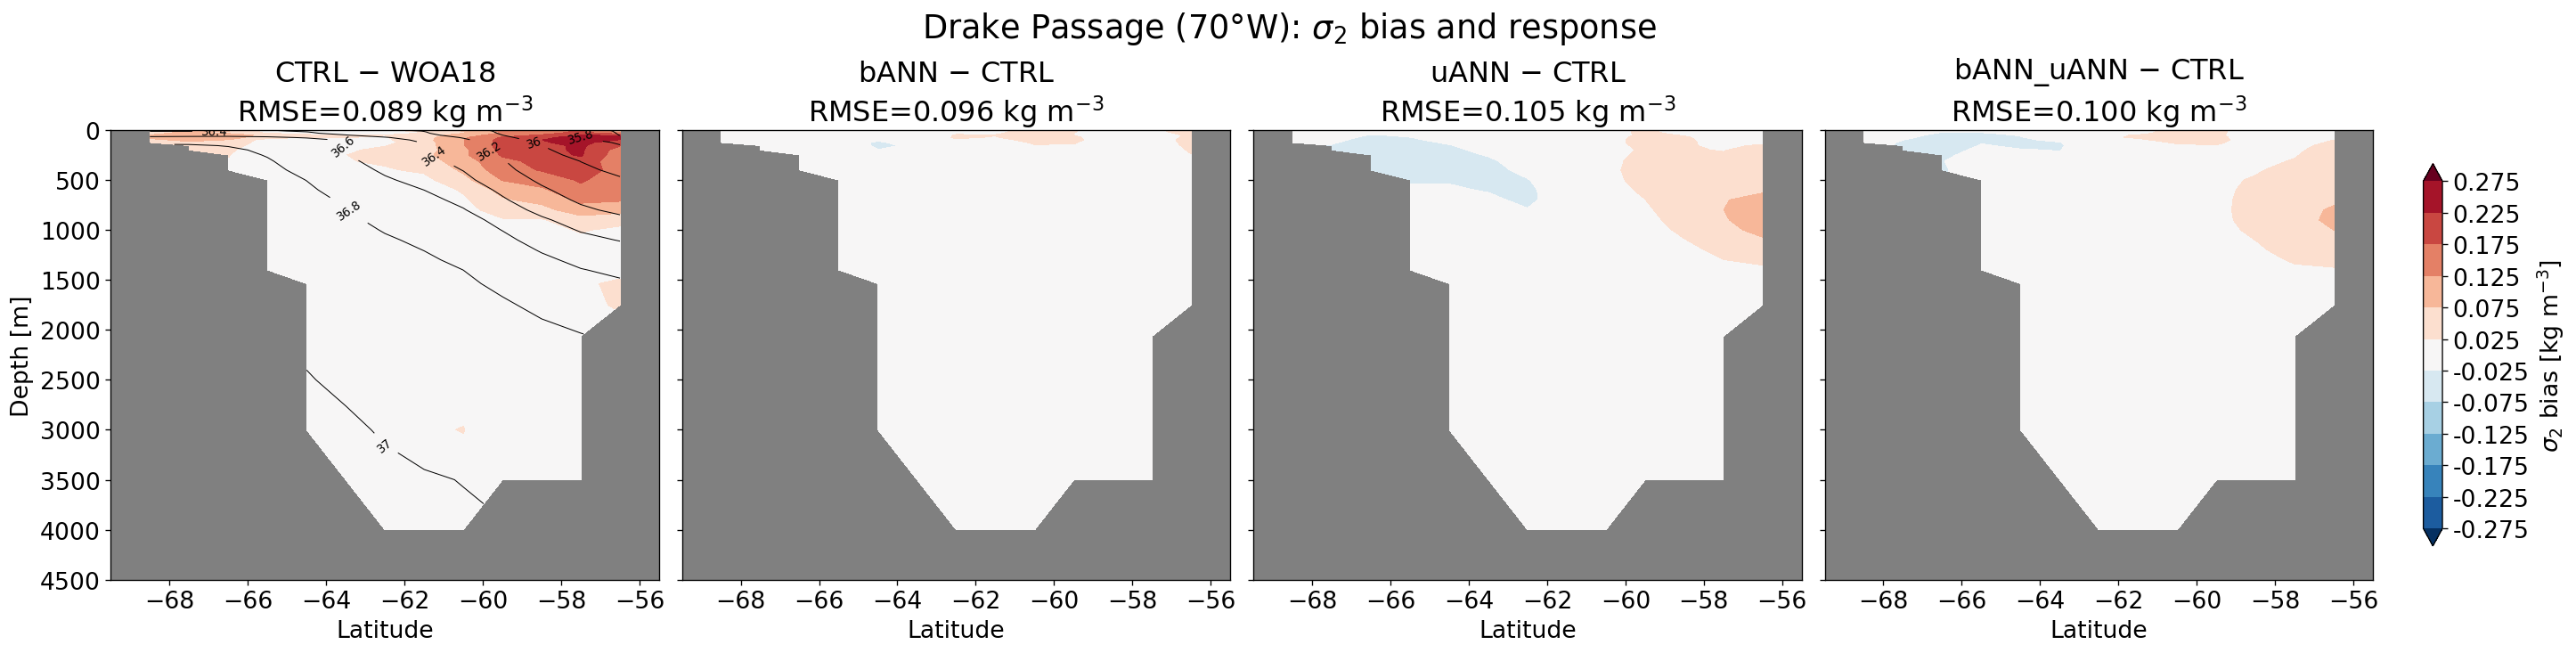

In [11]:
plot_sigma2_region(lambda f, e: lon_section(f, e, -70.0, -70.0, -55.0),
                   r'Drake Passage (70$\degree$W): $\sigma_2$ bias and response',
                   uniform_depth=True, obs_levels=np.arange(30.0, 37.61, 0.2),
                   depth_max=4500.0)


## Weddell Sea (42W)

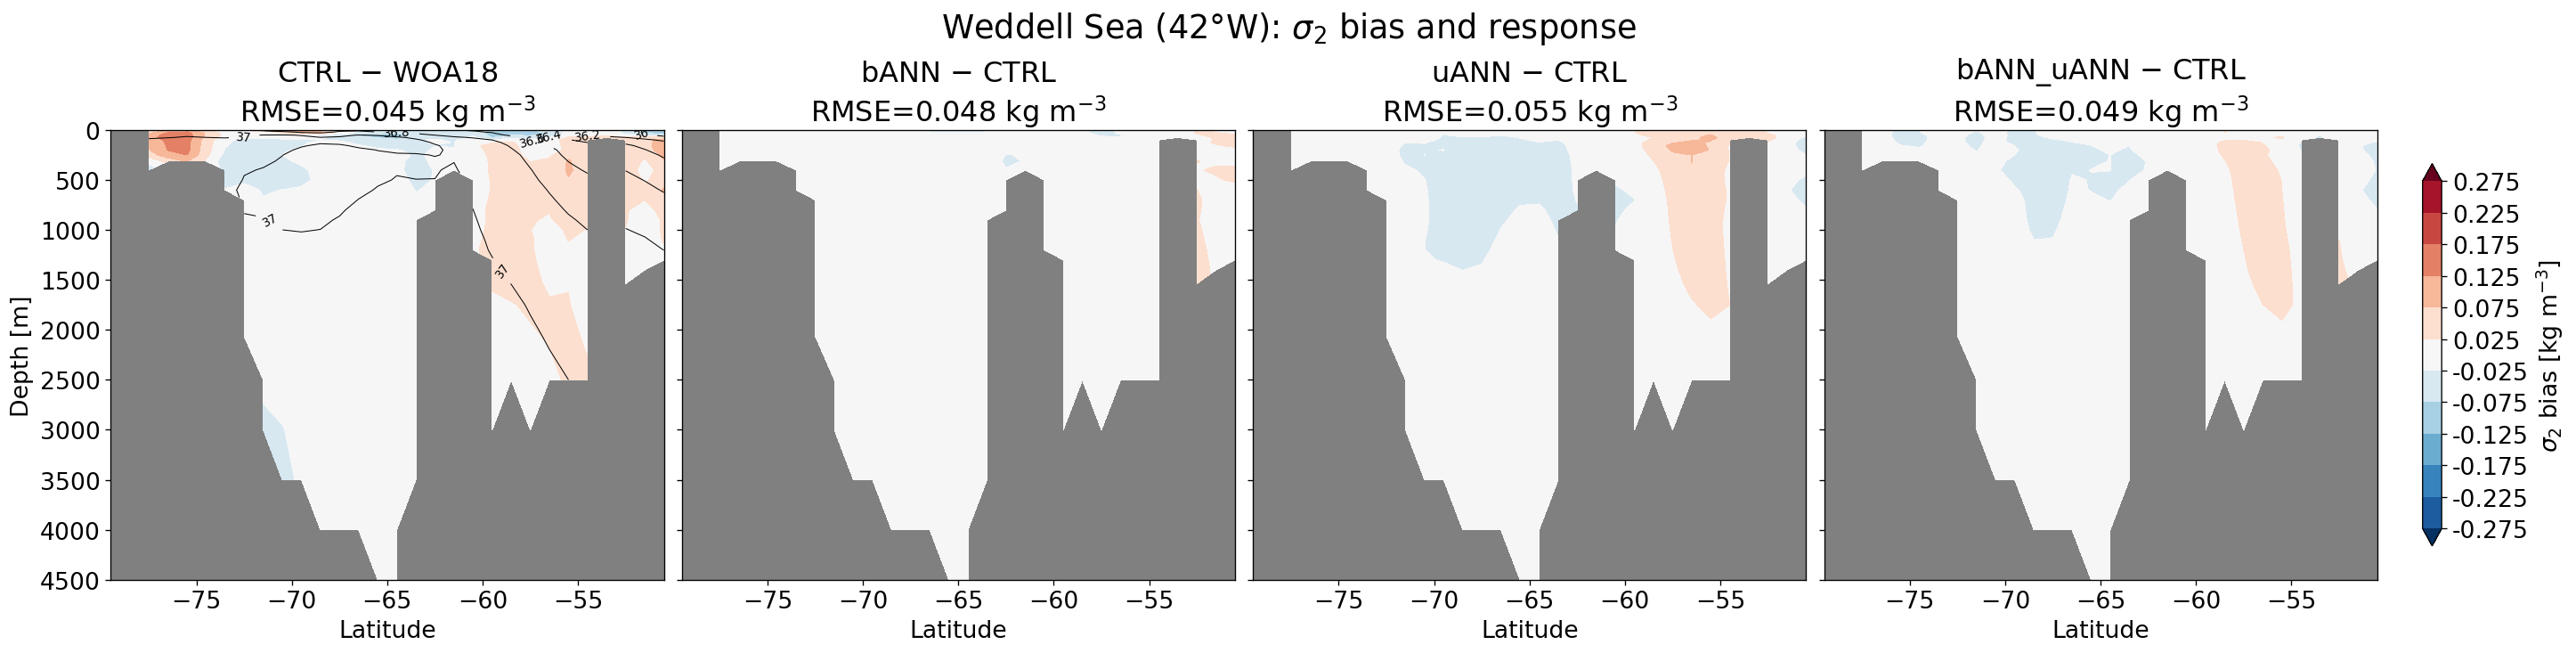

In [12]:
plot_sigma2_region(lambda f, e: lon_section(f, e, -42.0, -80.0, -50.0),
                   r'Weddell Sea (42$\degree$W): $\sigma_2$ bias and response',
                   uniform_depth=True, obs_levels=np.arange(30.0, 37.61, 0.2),
                   depth_max=4500.0)


## Southern Ocean (zonal average)

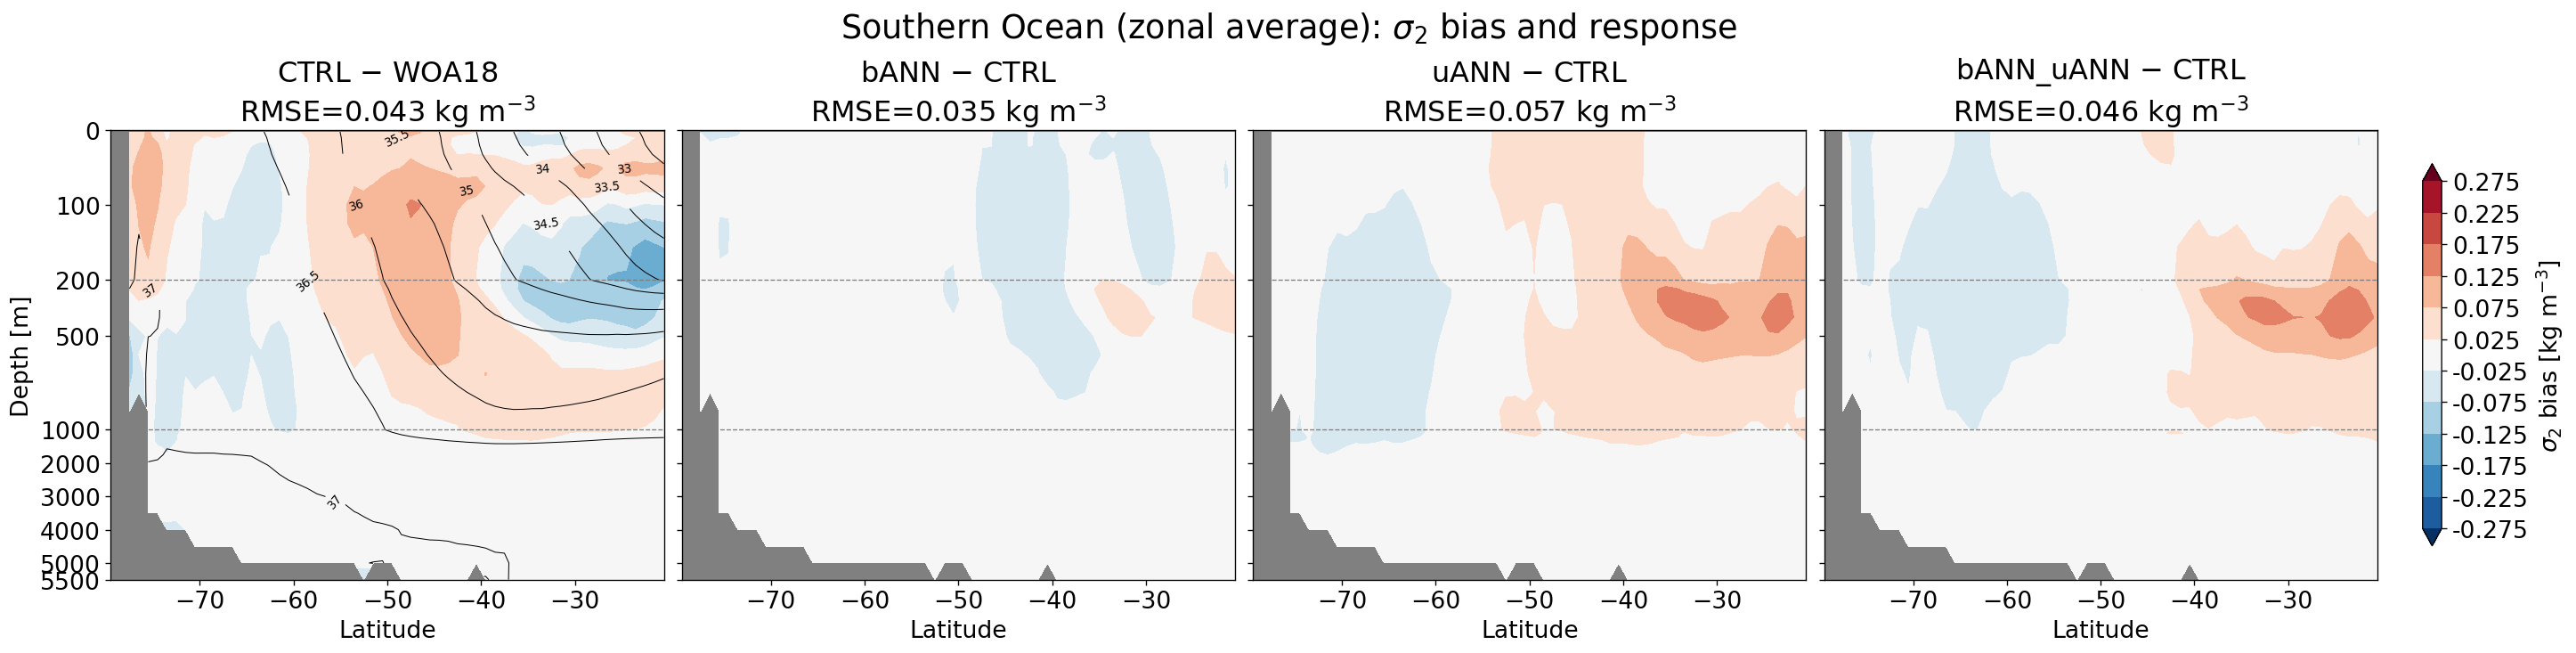

In [13]:
plot_sigma2_region(lambda f, e: basin_zonal(f, e, so_mask, -80.0, -20.0),
                   r'Southern Ocean (zonal average): $\sigma_2$ bias and response')


## North Atlantic (zonal average)

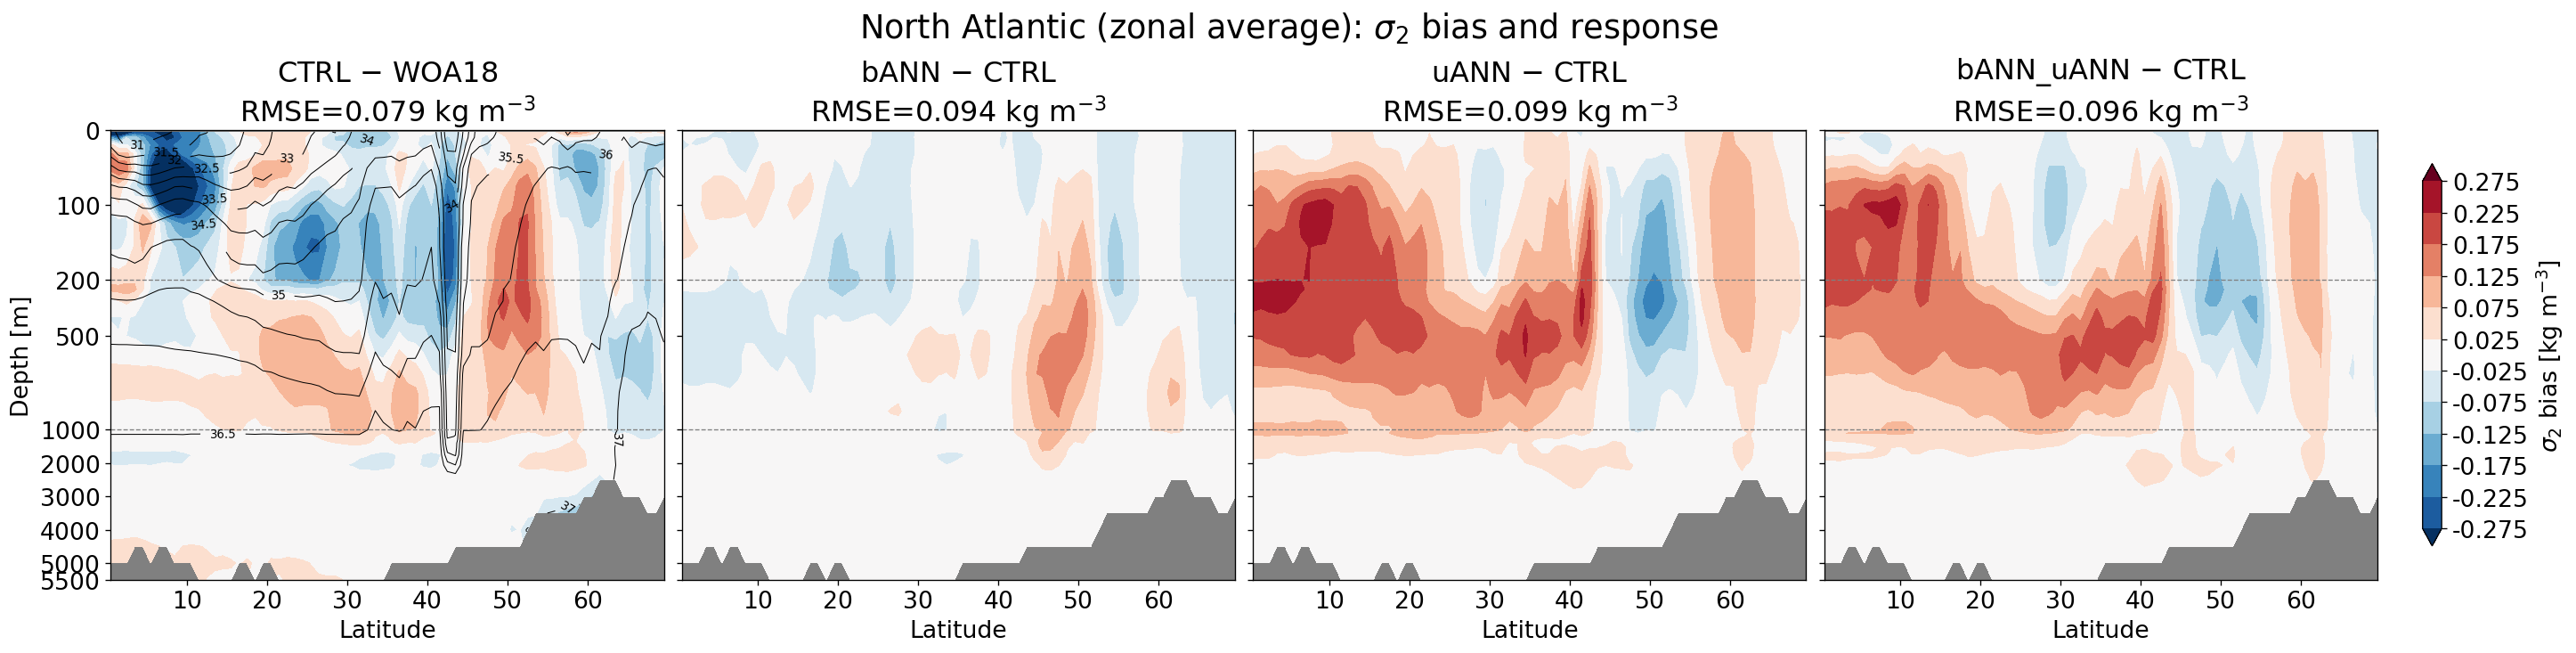

In [14]:
plot_sigma2_region(lambda f, e: basin_zonal(f, e, atl_mask, 0.0, 70.0),
                   r'North Atlantic (zonal average): $\sigma_2$ bias and response')


## Pacific Ocean (zonal average)

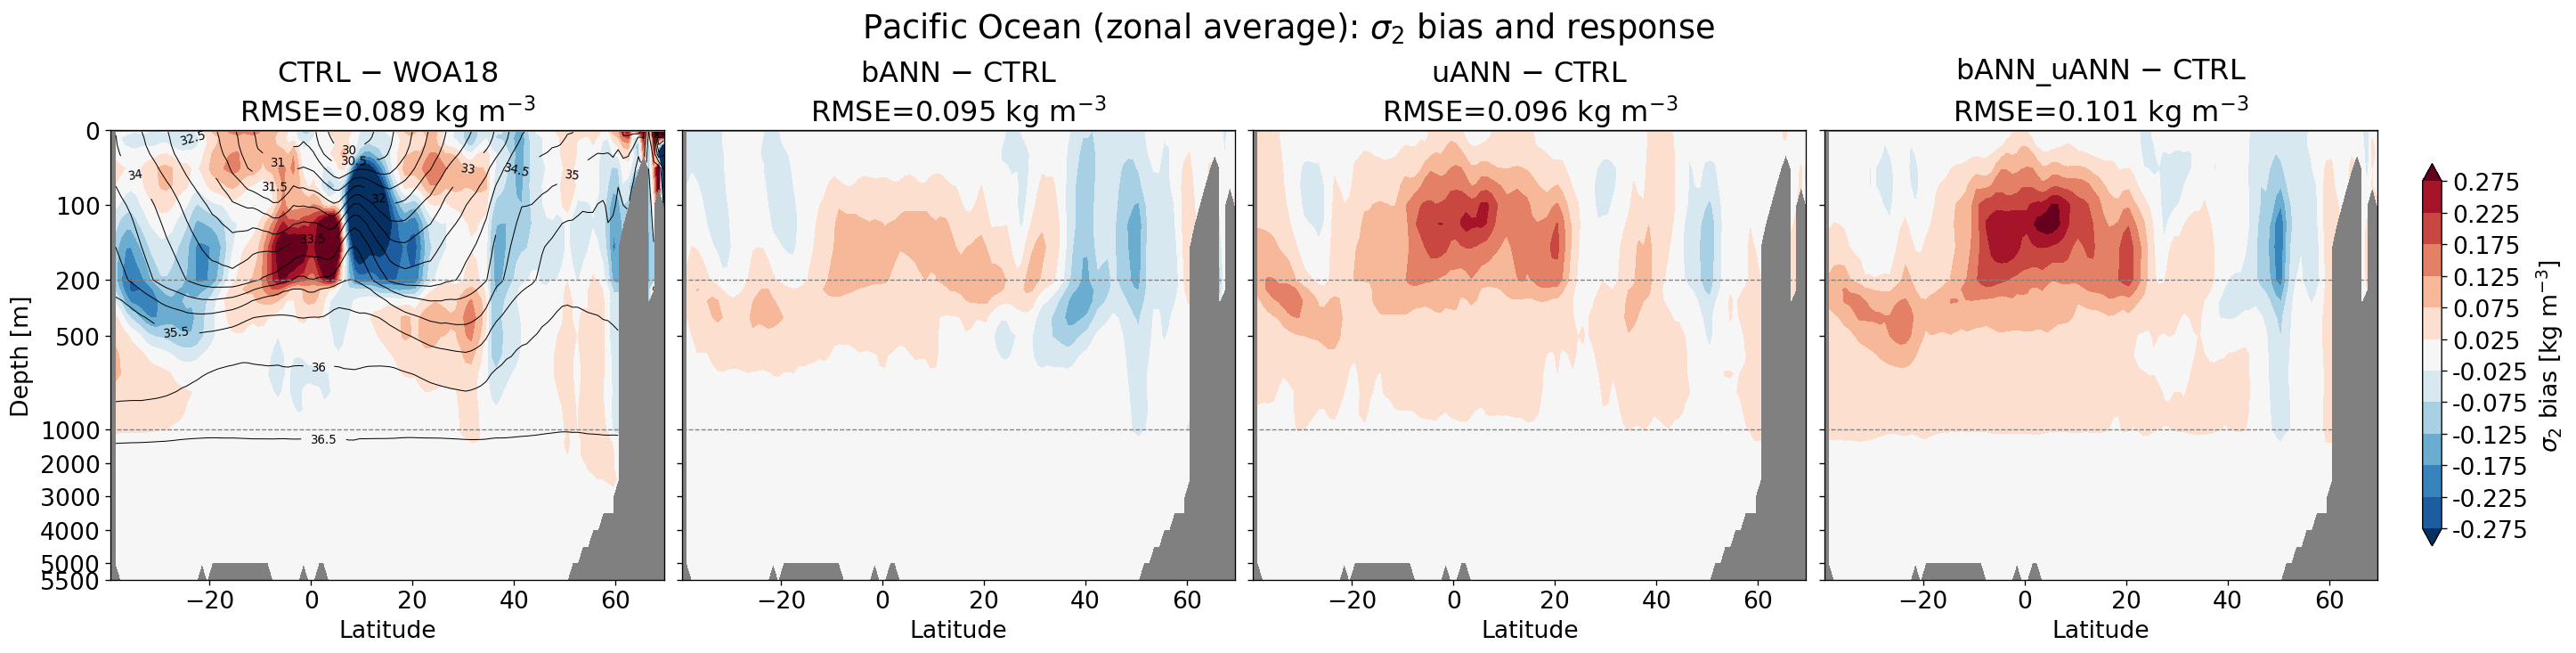

In [15]:
plot_sigma2_region(lambda f, e: basin_zonal(f, e, pac_mask, -40.0, 70.0),
                   r'Pacific Ocean (zonal average): $\sigma_2$ bias and response')


## Indian Ocean (zonal average)

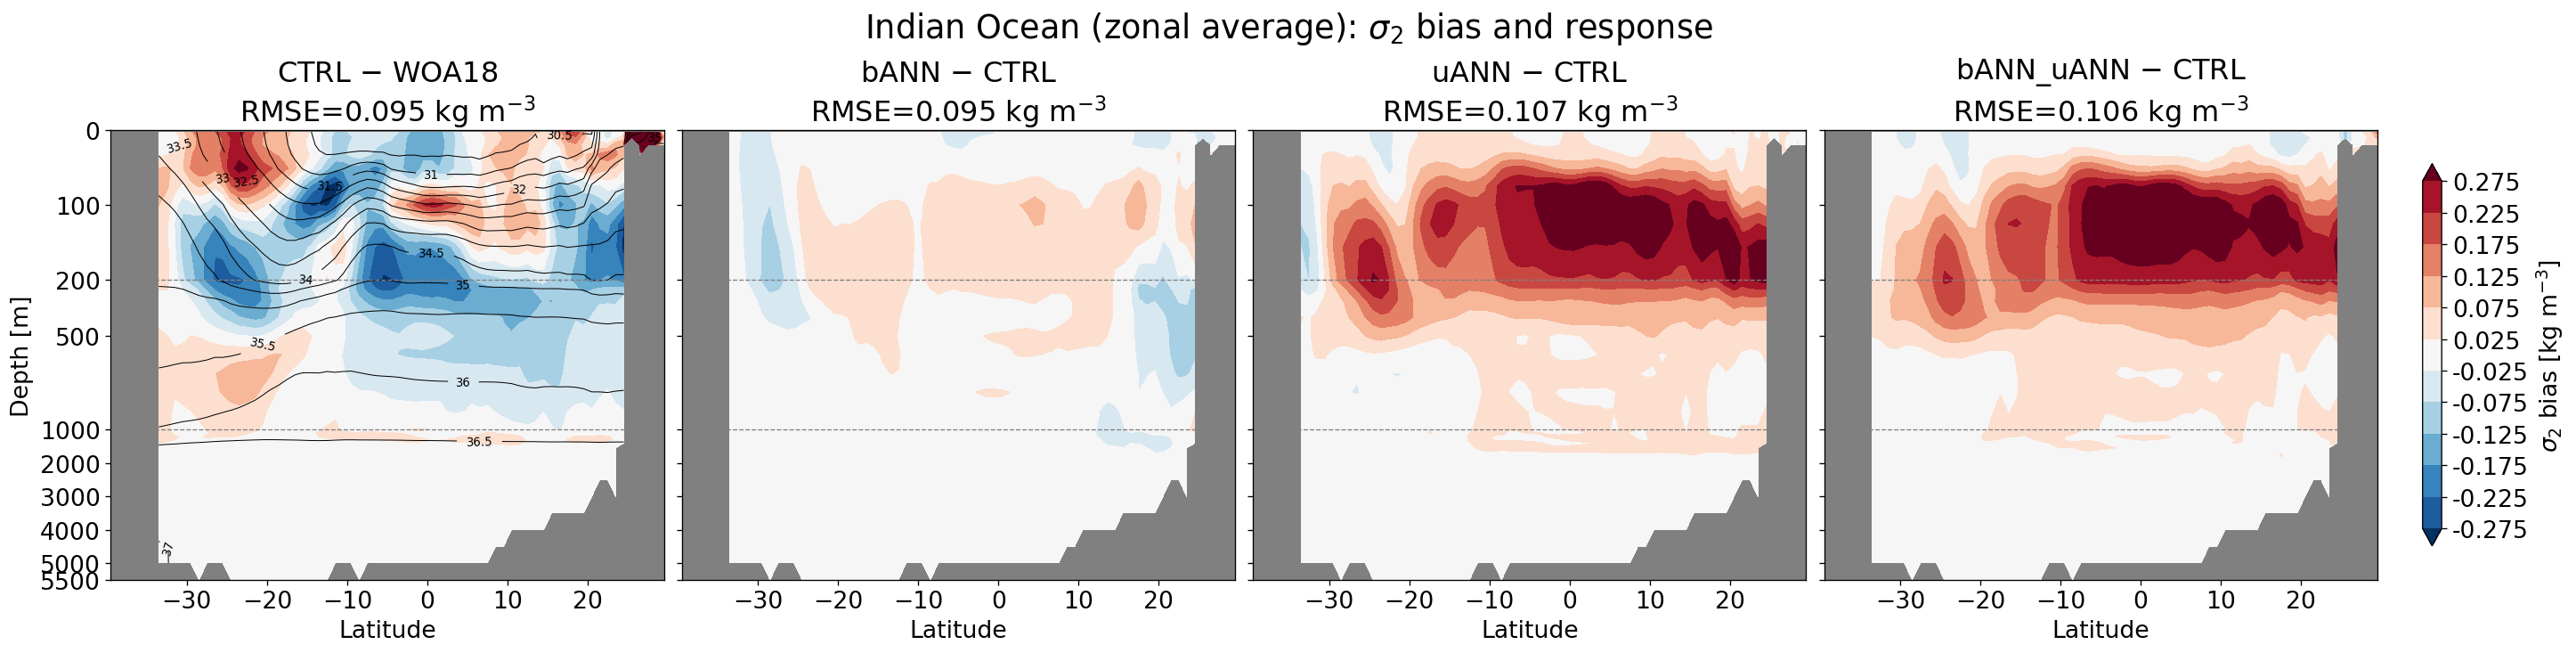

In [16]:
plot_sigma2_region(lambda f, e: basin_zonal(f, e, ind_mask, -40.0, 30.0),
                   r'Indian Ocean (zonal average): $\sigma_2$ bias and response')


## Equatorial Pacific (longitude-depth, 15S-15N average)

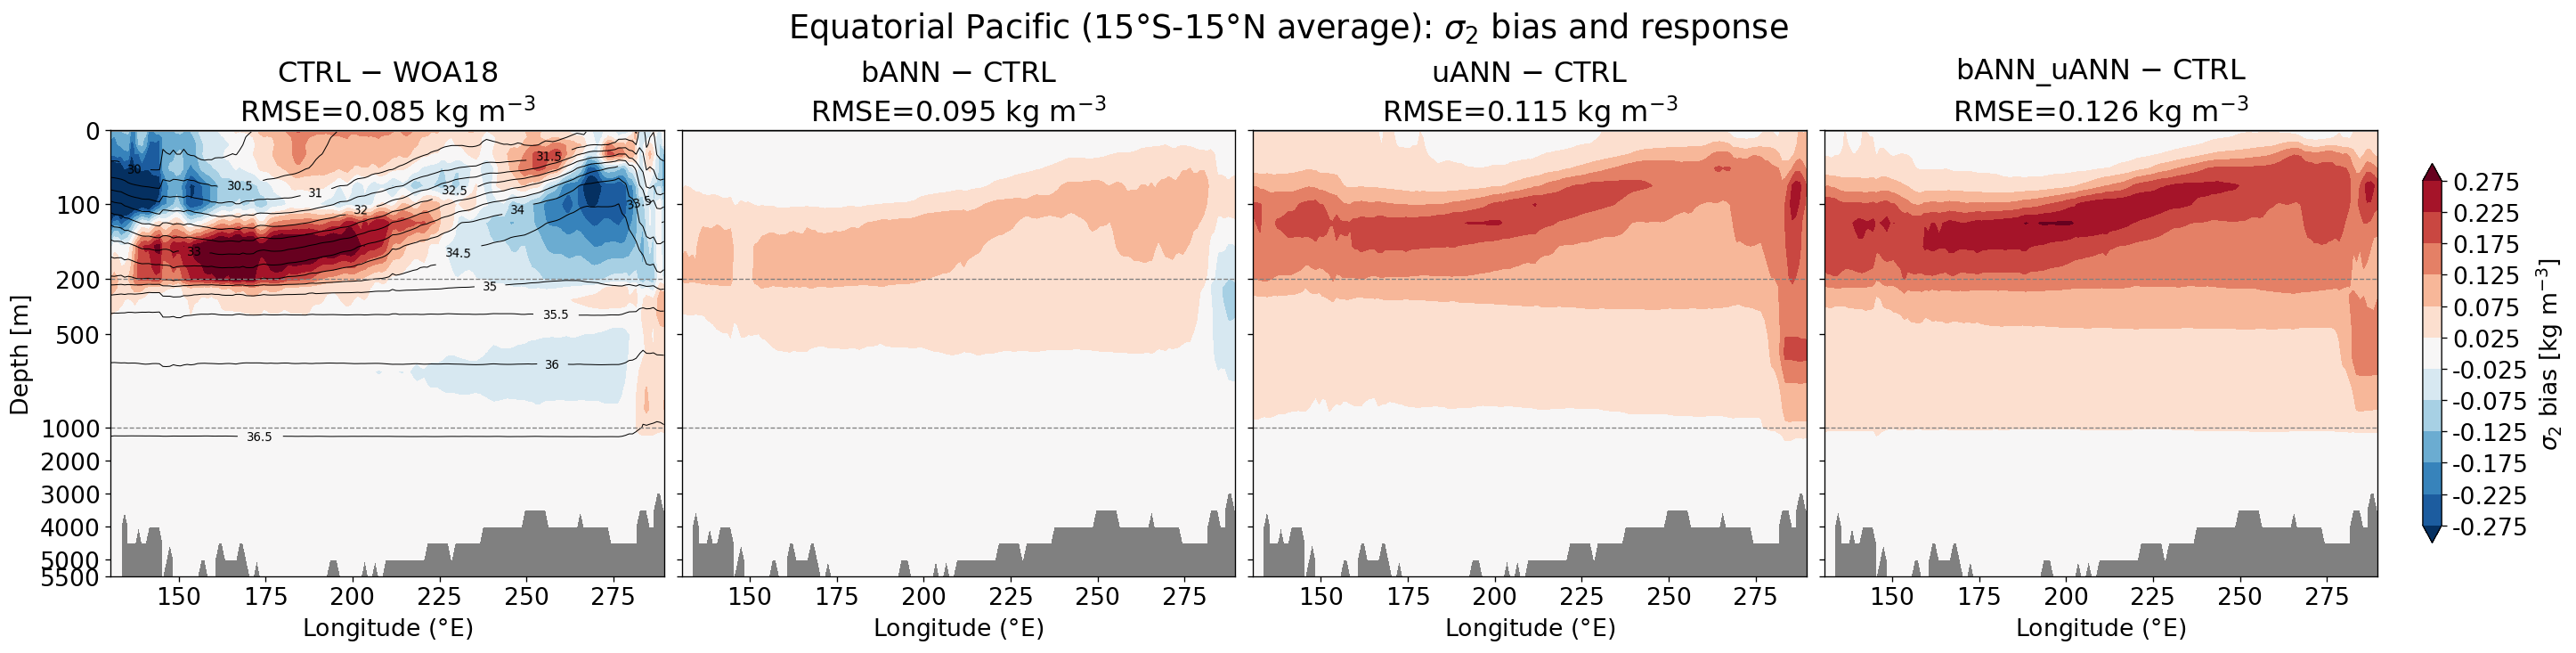

In [17]:
plot_sigma2_region(lambda f, e: lon_depth_ave(f, e, -15.0, 15.0, 130.0, 290.0),
                   r'Equatorial Pacific (15$\degree$S-15$\degree$N average): '
                   r'$\sigma_2$ bias and response',
                   x='lon', xlabel='Longitude ($\degree$E)')


## Equatorial Atlantic (longitude-depth, 15S-15N average)

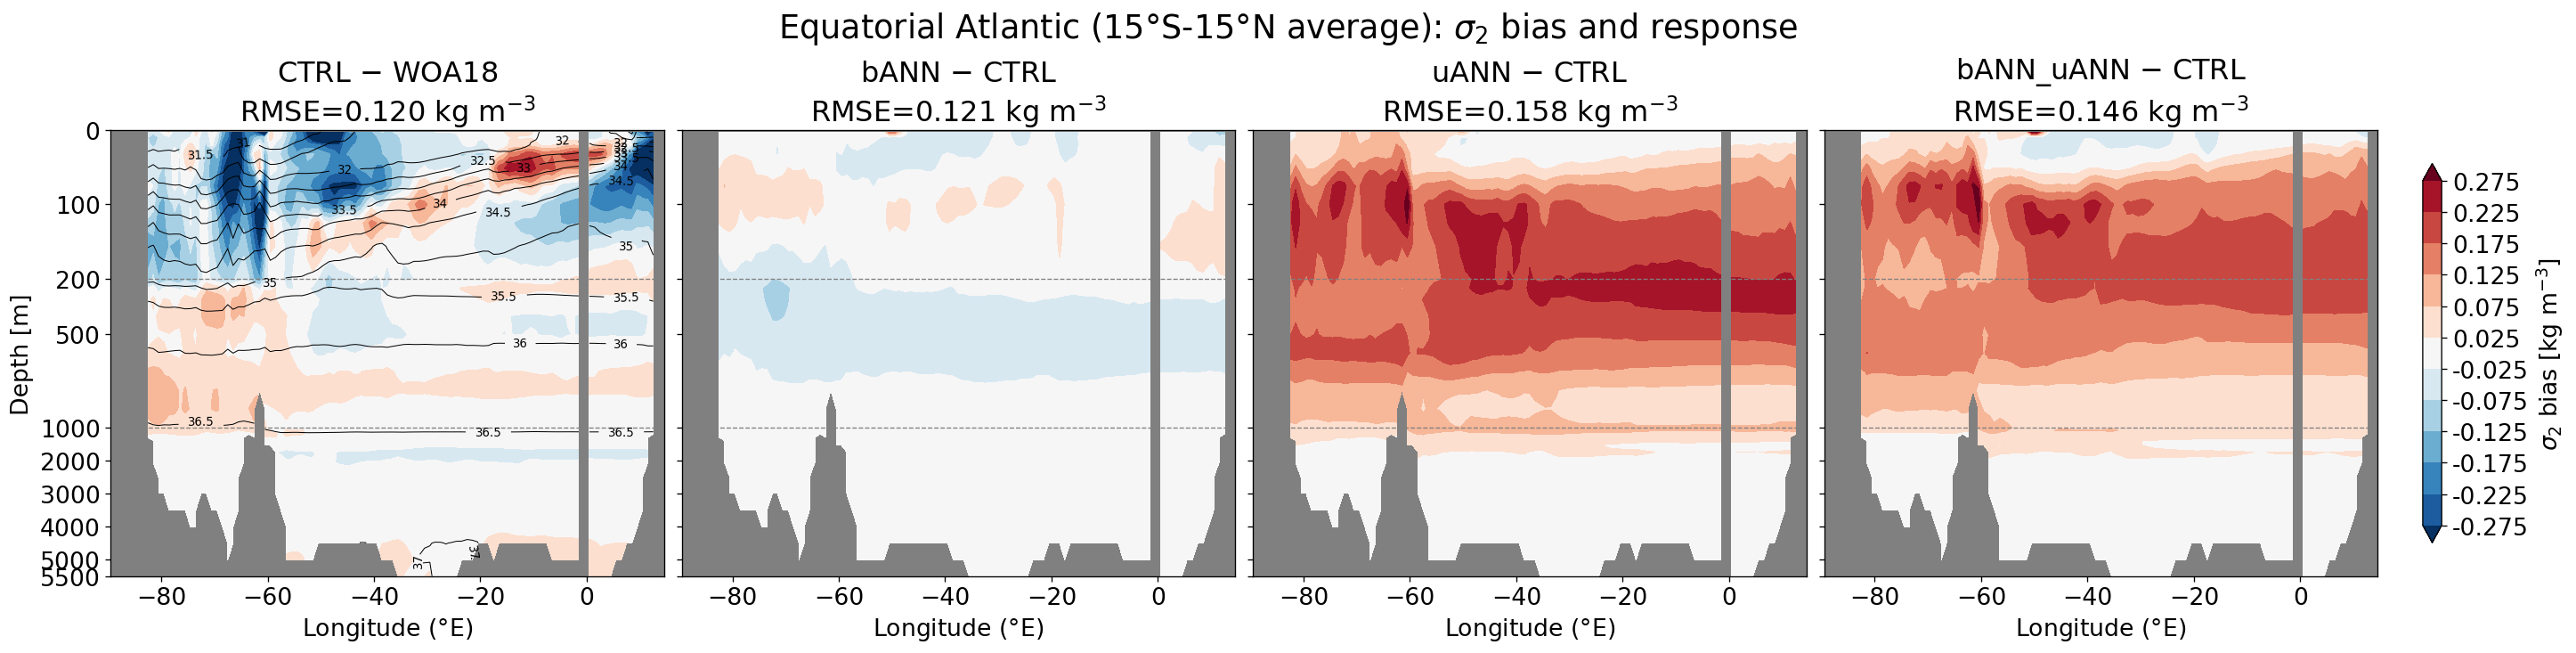

In [18]:
plot_sigma2_region(lambda f, e: lon_depth_ave(f, e, -15.0, 15.0, -90.0, 15.0,
                                               mask=atl_mask, wrap180=True),
                   r'Equatorial Atlantic (15$\degree$S-15$\degree$N average): '
                   r'$\sigma_2$ bias and response',
                   x='lon', xlabel='Longitude ($\degree$E)')
